
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/molecular_docking_tutorial/blob/main/practical_docking/05_EGFR_Mutants.ipynb)

# EGFR 변이체 — 약물 내성 도킹 분석

## 목적

EGFR의 WT(정상)와 내성 변이체(L858R, T790M, 이중 변이)에 1~3세대 TKI를 도킹하여,
**약물 내성 메커니즘**을 분자 수준에서 시뮬레이션합니다.

## 이론적 배경

### EGFR 변이와 TKI 내성
EGFR(Epidermal Growth Factor Receptor)은 비소세포폐암(NSCLC)의 주요 타겟입니다.

**변이 진행 과정:**
1. **L858R** (exon 21): 활성화 변이 → 1세대 TKI(Erlotinib, Gefitinib)에 감수성
2. **T790M** (Gatekeeper): 내성 변이 → 1세대 TKI 결합 차단
3. **3세대 TKI** (Osimertinib): T790M에 선택적 → 내성 극복

### Gatekeeper 변이란?
ATP binding site 입구의 790번 잔기(Thr→Met)가 변이되면:
- Met의 큰 side chain이 포켓 입구를 부분적으로 차단
- 1세대 TKI가 포켓에 들어가기 어려워짐
- 3세대 TKI는 다른 결합 모드로 이를 극복

### Cross-docking으로 내성 분석
각 약물을 각 변이체에 도킹하면:
- WT → T790M에서 스코어가 나빠지는 약물 = 내성에 취약
- T790M에서도 스코어가 유지되는 약물 = 내성 극복 후보

## 워크플로우
1. EGFR 구조 & 약물 패널 정의
2. 구조 준비 & 정렬
3. Docking Box 설정 + 3D 확인
4. Cross-docking (약물 × 변이체)
5. 내성 패턴 분석 (히트맵, 감수성 곡선)
6. 내보내기


## 0. 환경 설정


### 환경 설치


In [1]:
#@title 환경 설치 {display-mode: "form"}
import subprocess, sys, os

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(pkgs))

pip_install('rdkit', 'gemmi', 'openbabel-wheel')
pip_install('pdbfixer', 'openmm')
pip_install('py3Dmol', 'prolif', 'MDAnalysis')
pip_install('seaborn', 'pandas', 'matplotlib', 'requests')
try: pip_install('pymol-open-source')
except: pass

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
os.makedirs(BIN_DIR, exist_ok=True)
smina_path = os.path.join(BIN_DIR, 'smina')
if not os.path.exists(smina_path):
    import stat, urllib.request
    urllib.request.urlretrieve(
        'https://sourceforge.net/projects/smina/files/smina.static/download', smina_path)
    os.chmod(smina_path, os.stat(smina_path).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
os.environ['PATH'] = BIN_DIR + ':' + os.environ['PATH']
print('Done.')


Done.


### 라이브러리 로드


In [2]:
#@title 라이브러리 로드 {display-mode: "form"}
import warnings; warnings.filterwarnings('ignore')
import os, subprocess, urllib.request, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, SanitizeFlags
from openbabel import pybel
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import MDAnalysis as mda
from MDAnalysis.analysis import align as mda_align
import prolif as plf

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
WORK_DIR = '/content/egfr_mutants' if os.path.exists('/content') else os.path.join(os.path.expanduser('~'), 'egfr_mutants')
os.makedirs(WORK_DIR, exist_ok=True)
print('All libraries loaded.')


/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


All libraries loaded.


## 1. EGFR 구조 & 약물 패널 정의


### EGFR 변이체 구조 정의

분석할 EGFR 변이체와 PDB 구조를 정의합니다:
- **Wild-type (WT)**: 정상 EGFR
- **L858R**: exon 21 활성화 변이 (1세대 TKI에 감수성)
- **T790M**: Gatekeeper 변이 (1세대 TKI 내성의 주원인)
- **T790M/L858R**: 이중 변이 (3세대 TKI 타겟)


In [3]:
#@title 1-1. EGFR 변이체 구조 {display-mode: "form"}

EGFR_STRUCTURES = [
    {'label': 'WT_Erlotinib',    'pdb': '1M17', 'chain': 'A', 'mutation': 'Wild-type',    'generation': '1st gen'},
    {'label': 'L858R_Gefitinib', 'pdb': '2ITZ', 'chain': 'A', 'mutation': 'L858R',        'generation': '1st gen'},
    {'label': 'T790M_Neratinib', 'pdb': '2JIT', 'chain': 'A', 'mutation': 'T790M',        'generation': '2nd gen'},
    {'label': 'DM_WZ4002',       'pdb': '3IKA', 'chain': 'A', 'mutation': 'T790M/L858R',  'generation': '3rd gen-like'},
]

egfr_df = pd.DataFrame(EGFR_STRUCTURES)
egfr_df.index += 1
egfr_df


,label,pdb,chain,mutation,generation
1,WT_Erlotinib,1M17,A,Wild-type,1st gen
2,L858R_Gefitinib,2ITZ,A,L858R,1st gen
3,T790M_Neratinib,2JIT,A,T790M,2nd gen
4,DM_WZ4002,3IKA,A,T790M/L858R,3rd gen-like


### 약물 패널 정의

EGFR TKI 3세대를 정의합니다:
- **1세대 (Erlotinib, Gefitinib)**: 가역적 억제제. WT/L858R에 효과적, T790M 내성
- **2세대 (Afatinib)**: 비가역적 pan-ErbB 억제제. T790M에 약한 효과
- **3세대 (Osimertinib)**: T790M 선택적 비가역 억제제. WT는 보존


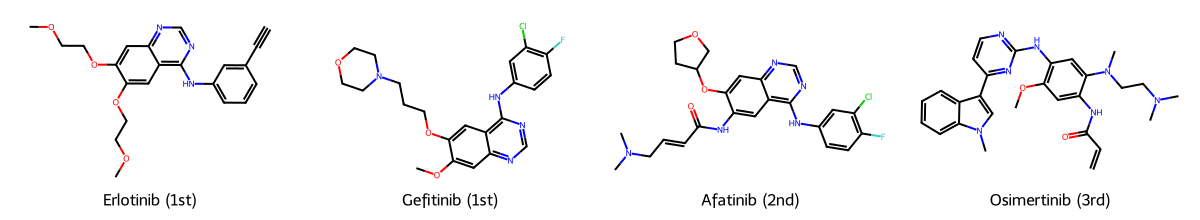

In [4]:
#@title 1-2. 약물 패널 정의 {display-mode: "form"}

DRUGS = {
    'Erlotinib':   {'smiles': 'C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1',                                    'gen': '1st', 'mechanism': 'Reversible'},
    'Gefitinib':   {'smiles': 'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1',                                'gen': '1st', 'mechanism': 'Reversible'},
    'Afatinib':    {'smiles': 'CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OC1CCOC1',                     'gen': '2nd', 'mechanism': 'Irreversible'},
    'Osimertinib': {'smiles': 'C=CC(=O)Nc1cc(OC)c(Nc2nccc(-c3cn(C)c4ccccc34)n2)cc1N(C)CCN(C)C',                'gen': '3rd', 'mechanism': 'Irreversible'},
}

drug_mols = []
drug_labels = []
for name, info in DRUGS.items():
    mol = Chem.MolFromSmiles(info['smiles'])
    if mol:
        drug_mols.append(mol)
        drug_labels.append(f"{name} ({info['gen']})")

Draw.MolsToGridImage(drug_mols, legends=drug_labels, molsPerRow=4, subImgSize=(300, 220))


## 2. 구조 준비 & 정렬


### EGFR 변이체 구조 정의

분석할 EGFR 변이체와 PDB 구조를 정의합니다:
- **Wild-type (WT)**: 정상 EGFR
- **L858R**: exon 21 활성화 변이 (1세대 TKI에 감수성)
- **T790M**: Gatekeeper 변이 (1세대 TKI 내성의 주원인)
- **T790M/L858R**: 이중 변이 (3세대 TKI 타겟)


In [5]:
#@title 2-1. 전체 구조 준비 {display-mode: "form"}
structures = {}

for i, cx in enumerate(EGFR_STRUCTURES):
    pdb_id = cx['pdb'].lower()
    label = cx['label']
    print(f'[{i+1}/{len(EGFR_STRUCTURES)}] {label} ({pdb_id.upper()})...', end=' ', flush=True)

    sdir = os.path.join(WORK_DIR, label)
    os.makedirs(sdir, exist_ok=True)

    try:
        pdb_path = os.path.join(sdir, f'{pdb_id}.pdb')
        if not os.path.exists(pdb_path):
            urllib.request.urlretrieve(f'https://files.rcsb.org/download/{pdb_id}.pdb', pdb_path)

        u = mda.Universe(pdb_path)
        prot_sel = u.select_atoms(f'protein and chainID {cx["chain"]}')
        clean_pdb = os.path.join(sdir, f'{pdb_id}_clean.pdb')
        prot_sel.write(clean_pdb)

        prot_H = os.path.join(sdir, f'{pdb_id}_clean_H.pdb')
        fixer = PDBFixer(filename=clean_pdb)
        fixer.findMissingResidues(); fixer.findNonstandardResidues()
        fixer.replaceNonstandardResidues(); fixer.removeHeterogens(True)
        fixer.findMissingAtoms(); fixer.addMissingAtoms(); fixer.addMissingHydrogens(7.4)
        with open(prot_H, 'w') as f:
            PDBFile.writeFile(fixer.topology, fixer.positions, f)

        rec_qt = os.path.join(sdir, f'{pdb_id}_rec.pdbqt')
        mol_ob = list(pybel.readfile(format='pdb', filename=prot_H))[0]
        out = pybel.Outputfile(filename=rec_qt+'.tmp', format='pdbqt', overwrite=True)
        out.write(mol_ob); out.close()
        with open(rec_qt+'.tmp') as f: raw = f.readlines()
        with open(rec_qt, 'w') as f:
            for l in raw:
                if not l.startswith(('ROOT','ENDROOT','BRANCH','ENDBRANCH','TORSDOF')): f.write(l)
        os.remove(rec_qt+'.tmp')

        # Co-crystal ligand coords for box
        lig_sel = u.select_atoms(f'not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI and chainID {cx["chain"]}')
        if len(lig_sel) < 3:
            lig_sel = u.select_atoms('not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI')

        # 여러 잔기가 있으면 가장 큰 것(약물)만 선택
        if len(lig_sel) > 0:
            resnames = list(set(lig_sel.resnames))
            if len(resnames) > 1:
                biggest = max(resnames, key=lambda r: len(lig_sel.select_atoms(f'resname {r}')))
                lig_sel = lig_sel.select_atoms(f'resname {biggest}')
                print(f'  Keeping largest ligand: {biggest} ({len(lig_sel)} atoms)')

        structures[label] = {
            'pdb_id': pdb_id, 'pdb_path': pdb_path, 'prot_H': prot_H, 'rec_qt': rec_qt,
            'dir': sdir, 'mutation': cx['mutation'],
            'lig_coords': lig_sel.positions if len(lig_sel) > 0 else None,
        }
        print('OK')
    except Exception as e:
        print(f'FAILED: {e}')

print(f'\n=== {len(structures)}/{len(EGFR_STRUCTURES)} prepared ===')


[1/4] WT_Erlotinib (1M17)... OK
[2/4] L858R_Gefitinib (2ITZ)... OK
[3/4] T790M_Neratinib (2JIT)... OK
[4/4] DM_WZ4002 (3IKA)... OK

=== 4/4 prepared ===


### 구조 정렬 (WT 기준)

Wild-type 구조를 기준으로 모든 변이체를 정렬합니다.
변이 잔기(예: 790번 위치)의 구조적 차이를 비교할 수 있습니다.


In [6]:
#@title 2-2. 구조 정렬 (WT 기준) {display-mode: "form"}
from pymol import cmd as pcmd

labels = list(structures.keys())
if not labels:
    print('ERROR: No structures prepared successfully.')
    ref_label = None
else:
    ref_label = labels[0]

    pcmd.delete('all')
    
    # Load protein + ligand (from original PDB) for each structure
    for label in labels:
        s = structures[label]
        pcmd.load(s['prot_H'], f'{label}_prot')
        pcmd.load(s['pdb_path'], f'{label}_full')
        cx_info = next(cx for cx in EGFR_STRUCTURES if cx['label'] == label)
        pcmd.remove(f'{label}_full and not (organic and chain {cx_info["chain"]})')
        pcmd.remove(f'{label}_full and resn HOH+WAT+SOL+GOL+PEG+EDO+PG4+DMS+ACT+BME+CL+NA+MG+ZN+CA+SO4')
    
    # Step 1: CE-Align all to reference + save aligned files
    align_rmsds = {}
    for label in labels:
        if label == ref_label:
            align_rmsds[(ref_label, ref_label)] = 0.0
            structures[ref_label]['prot_H_aligned'] = structures[ref_label]['prot_H']
            ref_lig = os.path.join(structures[ref_label]['dir'], f'{ref_label}_lig_aligned.mol2')
            pcmd.save(ref_lig, f'{ref_label}_full')
            structures[ref_label]['lig_aligned'] = ref_lig
            continue
        try:
            result = pcmd.cealign(f'{ref_label}_prot', f'{label}_prot')
            rmsd = float(result['RMSD']) if 'RMSD' in result else float(list(result.values())[0])
            pcmd.matrix_copy(f'{label}_prot', f'{label}_full')
            
            aligned_prot = structures[label]['prot_H'].replace('.pdb', '_aligned.pdb')
            aligned_lig = os.path.join(structures[label]['dir'], f'{label}_lig_aligned.mol2')
            pcmd.save(aligned_prot, f'{label}_prot')
            pcmd.save(aligned_lig, f'{label}_full')
            structures[label]['prot_H_aligned'] = aligned_prot
            structures[label]['lig_aligned'] = aligned_lig
            align_rmsds[(ref_label, label)] = round(rmsd, 2)
            align_rmsds[(label, ref_label)] = round(rmsd, 2)
            print(f'{label} aligned to {ref_label}: RMSD={rmsd:.2f} A')
        except Exception as e:
            print(f'{label} align failed: {e}')
            structures[label]['prot_H_aligned'] = structures[label]['prot_H']
    
    # Step 2: Full pairwise RMSD (reload aligned as fresh copies)
    pcmd.delete('all')
    for label in labels:
        pcmd.load(structures[label]['prot_H_aligned'], f'{label}_al')
    
    for i, id1 in enumerate(labels):
        for j, id2 in enumerate(labels):
            if i == j:
                align_rmsds[(id1, id2)] = 0.0
            elif (id1, id2) not in align_rmsds:
                try:
                    pcmd.create('tmp_mob', f'{id2}_al')
                    result = pcmd.cealign(f'{id1}_al', 'tmp_mob')
                    rv = float(result['RMSD']) if 'RMSD' in result else float(list(result.values())[0])
                    align_rmsds[(id1, id2)] = round(rv, 2)
                    align_rmsds[(id2, id1)] = round(rv, 2)
                    pcmd.delete('tmp_mob')
                except:
                    align_rmsds[(id1, id2)] = np.nan
                    pcmd.delete('tmp_mob')
    
    pcmd.delete('all')
    
    rmsd_matrix = pd.DataFrame(
        [[align_rmsds.get((id1, id2), np.nan) for id2 in labels] for id1 in labels],
        index=labels, columns=labels
    )
    print('\nAlignment RMSD Matrix:')
    print(rmsd_matrix.to_string(float_format='%.2f'))


L858R_Gefitinib aligned to WT_Erlotinib: RMSD=1.31 A
T790M_Neratinib aligned to WT_Erlotinib: RMSD=2.00 A
DM_WZ4002 aligned to WT_Erlotinib: RMSD=1.67 A


## 3. Docking Box


### Docking Box 설정

각 변이체의 결합 부위에 맞는 docking box를 설정합니다.

**설정값** (3-1. Box 설정):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `BOX_METHOD` | `auto` | 선택: auto/residue/manual | 도킹 박스 설정 방식 |
| `RESIDUE_LIST` | `790, 858, 855` | 문자열 | 박스 중심 잔기 번호 (쉼표 구분) |
| `PADDING` | `7.0` | 숫자 | 도킹 박스 여유 공간 (Å) |


In [7]:
#@title 3-1. Box 설정 {display-mode: "form"}
BOX_METHOD = "auto"  #@param ["auto", "residue", "manual"]
RESIDUE_LIST = "790, 858, 855"  #@param {type:"string"}
PADDING = 7.0  #@param {type:"number"}

def get_box_from_coords(coords, padding=7.0):
    minC, maxC = coords.min(axis=0), coords.max(axis=0)
    return (
        {'x': float((maxC[0]+minC[0])/2), 'y': float((maxC[1]+minC[1])/2), 'z': float((maxC[2]+minC[2])/2)},
        {'x': float(maxC[0]-minC[0]+2*padding), 'y': float(maxC[1]-minC[1]+2*padding), 'z': float(maxC[2]-minC[2]+2*padding)}
    )

# 정렬 후: reference 구조의 box를 공통 사용
ref_key = list(structures.keys())[0] if structures else None

if ref_key is None:
    print('ERROR: No structures available')
elif BOX_METHOD == "auto":
    if structures[ref_key]['lig_coords'] is not None:
        center, size = get_box_from_coords(structures[ref_key]['lig_coords'], PADDING)
        for _k, _s in structures.items():
            _s['center'] = center
            _s['size'] = size
        print(f'Auto box from {ref_key} (common for all aligned structures)')
    else:
        print(f'WARNING: {ref_key} has no ligand coords')
elif BOX_METHOD == "residue":
    res_nums = [int(r.strip()) for r in RESIDUE_LIST.split(',')]
    ref = mda.Universe(structures[ref_key]['prot_H'])
    sel = ref.select_atoms(' or '.join([f'resid {r}' for r in res_nums]))
    if len(sel) > 0:
        center, size = get_box_from_coords(sel.positions, PADDING)
        for _k, _s in structures.items():
            _s['center'] = center
            _s['size'] = size
        print(f'Residue box from {res_nums}')

if ref_key and 'center' in structures[ref_key]:
    center = structures[ref_key]['center']
    size = structures[ref_key]['size']
    print(f'Center: ({center["x"]:.1f}, {center["y"]:.1f}, {center["z"]:.1f})')
    print(f'Size:   ({size["x"]:.1f}, {size["y"]:.1f}, {size["z"]:.1f})')

Auto box from WT_Erlotinib (common for all aligned structures)
Center: (21.7, 0.3, 52.1)
Size:   (29.7, 18.7, 21.1)


### Box 3D 시각화


In [8]:
#@title 3-2. Box 3D 시각화 {display-mode: "form"}
first = list(structures.keys())[0]
s = structures[first]

view = py3Dmol.view(width=800, height=600)
with open(s['prot_H']) as f: view.addModel(f.read(), 'pdb')
view.setStyle({'model': 0}, {'cartoon': {'color': 'white', 'opacity': 0.6}})
view.addBox({
    'center': {'x': s['center']['x'], 'y': s['center']['y'], 'z': s['center']['z']},
    'dimensions': {'w': s['size']['x'], 'h': s['size']['y'], 'd': s['size']['z']},
    'color': 'blue', 'opacity': 0.15
})
print(f'{first}: Box 시각화')
view.zoomTo()
view.show()


WT_Erlotinib: Box 시각화


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 4. Cross-docking (약물 × 변이체)


### Cross-docking (약물 × 변이체)

4개 약물 × 4개 EGFR 구조 = 16회 도킹을 수행합니다.
각 약물이 WT와 변이체에서 어떻게 다르게 결합하는지 비교합니다.

> **핵심 질문**: "T790M 변이에서 1세대 약물은 왜 효과가 없는가?"
> "Osimertinib은 왜 T790M에 선택적인가?"

**설정값** (4-1. 전체 약물 × 변이체 도킹):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `EXHAUSTIVENESS` | `16` | 정수 | 도킹 탐색 깊이 (높을수록 정확, 느림) |
| `N_POSES` | `5` | 정수 | 생성할 도킹 포즈 수 |
| `N_CPUS` | `0` | 정수 | CPU 코어 수 (0=자동) |


In [9]:
#@title 4-1. 전체 약물 × 변이체 도킹 {display-mode: "form"}
EXHAUSTIVENESS = 16  #@param {type:"integer"}
N_POSES = 5          #@param {type:"integer"}
N_CPUS = 0           #@param {type:"integer"}

smina = os.path.join(BIN_DIR, 'smina')
xdock_results = []
t0 = time.time()

# Prepare drug SDFs
drug_sdfs = {}
for drug_name, drug_info in DRUGS.items():
    rdmol = Chem.MolFromSmiles(drug_info['smiles'])
    if rdmol is None: continue
    rdmol = Chem.AddHs(rdmol)
    AllChem.EmbedMolecule(rdmol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(rdmol)

    lig_sdf = os.path.join(WORK_DIR, f'{drug_name}.sdf')
    writer = Chem.SDWriter(lig_sdf)
    writer.write(rdmol)
    writer.close()
    drug_sdfs[drug_name] = lig_sdf

print(f'{len(drug_sdfs)} drugs prepared')

# Cross-dock
total = len(drug_sdfs) * len(structures)
done = 0

for drug_name, lig_sdf in drug_sdfs.items():
    for label, s in structures.items():
        done += 1
        print(f'[{done}/{total}] {drug_name} → {label}...', flush=True)

        # Receptor PDBQT from aligned protein (always regenerate)
        rec_qt = os.path.join(s['dir'], f'{s["pdb_id"]}_rec_aligned.pdbqt')
        obmol = list(pybel.readfile(format='pdb', filename=s.get('prot_H_aligned', s['prot_H'])))[0]
        out = pybel.Outputfile(filename=rec_qt+'.tmp', format='pdbqt', overwrite=True)
        out.write(obmol); out.close()
        skip_tags = ('ROOT','ENDROOT','BRANCH','ENDBRANCH','TORSDOF')
        with open(rec_qt+'.tmp') as f: raw = f.readlines()
        with open(rec_qt, 'w') as f:
            for l in raw:
                if not l.startswith(skip_tags): f.write(l)
        os.remove(rec_qt+'.tmp')

        sdf_out = os.path.join(s['dir'], f'{drug_name}_docked.sdf')
        os.system(f'{smina} -r {rec_qt} -l {lig_sdf} -o {sdf_out} --center_x {s["center"]["x"]} --center_y {s["center"]["y"]} --center_z {s["center"]["z"]} --size_x {s["size"]["x"]} --size_y {s["size"]["y"]} --size_z {s["size"]["z"]} --exhaustiveness {EXHAUSTIVENESS} --num_modes {N_POSES} --cpu {N_CPUS}')

        # Parse all poses
        scores = []
        if os.path.exists(sdf_out) and os.path.getsize(sdf_out) > 0:
            suppl = list(Chem.SDMolSupplier(sdf_out, removeHs=False))
            for pose_mol in suppl:
                if pose_mol is None: continue
                p = pose_mol.GetPropsAsDict()
                if 'minimizedAffinity' in p:
                    try: scores.append(float(p['minimizedAffinity']))
                    except: pass

        xdock_results.append({
            'Drug': drug_name, 'Structure': label, 'Mutation': s['mutation'],
            'Generation': DRUGS[drug_name]['gen'],
            'Best Score': round(min(scores), 2) if scores else None,
            'Mean Score': round(sum(scores)/len(scores), 2) if scores else None,
            'Poses': len(scores),
        })
        if scores:
            print(f'  → {len(scores)} poses: best={min(scores):.2f}')
        else:
            print(f'  → FAILED')

elapsed = time.time() - t0
print(f'\n=== {len([r for r in xdock_results if r["Best Score"]])} / {total} docked in {elapsed:.0f}s ===')

4 drugs prepared
[1/16] Erlotinib → WT_Erlotinib...
  → 5 poses: best=-6.91
[2/16] Erlotinib → L858R_Gefitinib...


[02:00:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:00:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:00:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:00:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:00:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  → 5 poses: best=-6.96
[3/16] Erlotinib → T790M_Neratinib...


[02:04:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:04:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:04:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:04:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[02:04:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  → 5 poses: best=-7.02
[4/16] Erlotinib → DM_WZ4002...


...

[03:06:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:06:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:06:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:06:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:06:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  → 5 poses: best=-8.41
[16/16] Osimertinib → DM_WZ4002...


[03:14:23] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:14:23] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:14:23] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:14:23] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:14:23] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


  → 5 poses: best=-8.51

=== 16 / 16 docked in 5116s ===


[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


### Crystal 포즈 스코어링

각 구조의 co-crystal 리간드를 원래 위치에서 `--score_only`로 스코어링합니다.
도킹 포즈의 스코어와 비교하여 scoring function의 신뢰성을 확인합니다.


In [10]:
#@title 4-2. Crystal 포즈 스코어링 {display-mode: "form"}
print('Crystal ligand scoring (--score_only, aligned coords)...', flush=True)

for label, s in structures.items():
    # 정렬된 리간드 → SDF
    crystal_sdf = os.path.join(s['dir'], f'{label}_crystal.sdf')
    lig_path = s.get('lig_aligned')

    if not lig_path or not os.path.exists(lig_path):
        print(f'{label}: no aligned ligand')
        s['crystal_score'] = None
        continue

    try:
        obmol = list(pybel.readfile(format='mol2', filename=lig_path))[0]
        lout = pybel.Outputfile(filename=crystal_sdf, format='sdf', overwrite=True)
        lout.write(obmol); lout.close()
    except Exception as e:
        print(f'{label}: crystal SDF failed - {e}')
        s['crystal_score'] = None
        continue

    # 정렬된 receptor PDBQT
    rec_qt = os.path.join(s['dir'], f'{s["pdb_id"]}_rec_aligned.pdbqt')
    if not os.path.exists(rec_qt):
        # Regenerate from aligned protein
        try:
            obmol = list(pybel.readfile(format='pdb', filename=s.get('prot_H_aligned', s['prot_H'])))[0]
            out = pybel.Outputfile(filename=rec_qt+'.tmp', format='pdbqt', overwrite=True)
            out.write(obmol); out.close()
            with open(rec_qt+'.tmp') as f: raw = f.readlines()
            with open(rec_qt, 'w') as f:
                for l in raw:
                    if not l.startswith(('ROOT','ENDROOT','BRANCH','ENDBRANCH','TORSDOF')): f.write(l)
            os.remove(rec_qt+'.tmp')
        except:
            pass

    score_out = os.path.join(s['dir'], f'{label}_crystal_scored.sdf')
    os.system(f'{smina} -r {rec_qt} -l {crystal_sdf} -o {score_out} --score_only 2>/dev/null')

    crystal_score = None
    if os.path.exists(score_out) and os.path.getsize(score_out) > 0:
        suppl = list(Chem.SDMolSupplier(score_out, removeHs=False))
        if suppl and suppl[0]:
            props = suppl[0].GetPropsAsDict()
            if 'minimizedAffinity' in props:
                try: crystal_score = float(props['minimizedAffinity'])
                except: pass

    s['crystal_score'] = crystal_score
    if crystal_score is not None:
        print(f'{label}: crystal={crystal_score:.2f} kcal/mol')
    else:
        print(f'{label}: scoring failed')

Crystal ligand scoring (--score_only, aligned coords)...


[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


WT_Erlotinib: crystal=-5.62 kcal/mol


[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


L858R_Gefitinib: crystal=0.00 kcal/mol
T790M_Neratinib: crystal SDF failed - list index out of range
DM_WZ4002: crystal=0.00 kcal/mol


[03:21:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


## 5. 내성 패턴 분석


### EGFR 변이체 구조 정의

분석할 EGFR 변이체와 PDB 구조를 정의합니다:
- **Wild-type (WT)**: 정상 EGFR
- **L858R**: exon 21 활성화 변이 (1세대 TKI에 감수성)
- **T790M**: Gatekeeper 변이 (1세대 TKI 내성의 주원인)
- **T790M/L858R**: 이중 변이 (3세대 TKI 타겟)


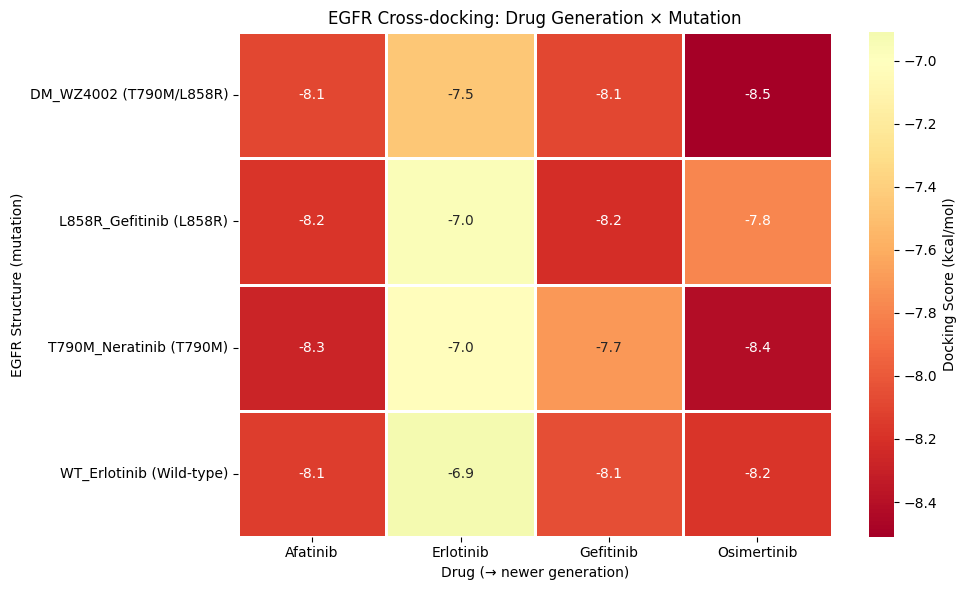

In [11]:
#@title 5-1. Cross-docking 히트맵 {display-mode: "form"}
xdf = pd.DataFrame(xdock_results)

# Pivot: rows=structure, columns=drug
matrix = xdf.pivot_table(index='Structure', columns='Drug', values='Best Score', aggfunc='first')

# Annotate mutation on index
mut_map = {cx['label']: cx['mutation'] for cx in EGFR_STRUCTURES}
row_labels = [f"{l} ({mut_map.get(l, '')})" for l in matrix.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
            center=-7.0, ax=ax, linewidths=0.8, yticklabels=row_labels,
            cbar_kws={'label': 'Docking Score (kcal/mol)'})
ax.set_xlabel('Drug (→ newer generation)')
ax.set_ylabel('EGFR Structure (mutation)')
ax.set_title('EGFR Cross-docking: Drug Generation × Mutation')
plt.tight_layout()
plt.show()


### 약물 세대별 변이 감수성

각 변이체에서 1~3세대 약물의 결합력 변화를 선 그래프로 표시합니다.
- 1세대: WT/L858R → T790M에서 스코어 상승 (내성)
- 3세대: T790M에서 스코어 유지/감소 (극복)


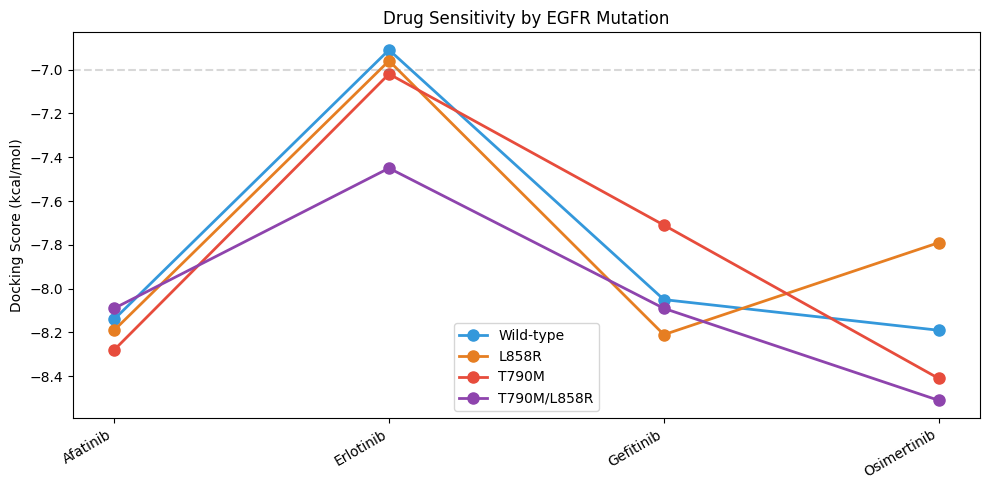


관찰 포인트:
• 1세대(Erlotinib/Gefitinib): WT/L858R에 효과적, T790M에 약함
• 3세대(Osimertinib): T790M에 선택적


In [12]:
#@title 5-2. 약물 세대별 변이 감수성 {display-mode: "form"}
fig, ax = plt.subplots(figsize=(10, 5))

mut_colors = {'Wild-type': '#3498DB', 'L858R': '#E67E22', 'T790M': '#E74C3C', 'T790M/L858R': '#8E44AD'}

for mut in xdf['Mutation'].unique():
    sub = xdf[xdf['Mutation'] == mut].dropna(subset=['Best Score'])
    if sub.empty: continue
    avg = sub.groupby('Drug')['Best Score'].mean()
    ax.plot(avg.index, avg.values, 'o-', label=mut, color=mut_colors.get(mut, 'gray'), markersize=8, linewidth=2)

ax.set_ylabel('Docking Score (kcal/mol)')
ax.set_title('Drug Sensitivity by EGFR Mutation')
ax.legend()
ax.axhline(y=-7.0, color='gray', linestyle='--', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\n관찰 포인트:')
print('• 1세대(Erlotinib/Gefitinib): WT/L858R에 효과적, T790M에 약함')
print('• 3세대(Osimertinib): T790M에 선택적')


## 6. 내보내기


### 결과 내보내기

CSV + PyMOL 스크립트 + ZIP 파일로 저장합니다.


In [13]:
#@title 6-1. 결과 내보내기 {display-mode: "form"}
import shutil

csv_path = os.path.join(WORK_DIR, 'egfr_crossdock.csv')
xdf.to_csv(csv_path, index=False)
matrix.to_csv(os.path.join(WORK_DIR, 'egfr_matrix.csv'))
print(f'CSV: {csv_path}')

pml_path = os.path.join(WORK_DIR, 'egfr_pymol.pml')
with open(pml_path, 'w') as f:
    f.write('reinitialize\nbg_color white\n\n')
    pml_colors = ['palegreen','salmon','lightblue','lightorange']
    for i, (label, s) in enumerate(structures.items()):
        prot = s.get('prot_H_aligned', s['prot_H'])
        f.write(f'load {prot}, {label}\ncolor {pml_colors[i%len(pml_colors)]}, {label}\nshow cartoon, {label}\n\n')
print(f'PyMOL: {pml_path}')

zip_path = os.path.join(os.path.dirname(WORK_DIR), 'egfr_mutants_results')

# 단백질 PDB + 도킹 포즈를 뷰어용 폴더에 복사
import glob as _glob
results_dir = os.path.join(WORK_DIR, 'results_for_viewer')
os.makedirs(results_dir, exist_ok=True)
for _name, _s in structures.items():
    _prot = _s.get('prot_H_aligned', _s['prot_H'])
    if os.path.exists(_prot): shutil.copy2(_prot, os.path.join(results_dir, f'{_name}_protein.pdb'))
for _sdf in _glob.glob(os.path.join(WORK_DIR, '**/*_docked.sdf'), recursive=True):
    shutil.copy2(_sdf, results_dir)
print(f'뷰어용 파일: {results_dir}/')
print('  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기')

shutil.make_archive(zip_path, 'zip', WORK_DIR)
print(f'Archive: {zip_path}.zip')
try:
    from google.colab import files
    files.download(f'{zip_path}.zip')
except ImportError:
    print(f'Results at: {WORK_DIR}')


CSV: /content/egfr_mutants/egfr_crossdock.csv
PyMOL: /content/egfr_mutants/egfr_pymol.pml
뷰어용 파일: /content/egfr_mutants/results_for_viewer/
  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기
Archive: /content/egfr_mutants_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>